In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import random
warnings.filterwarnings('ignore')
random.seed(200)

# The proposed target metric is ROC-AUC
ROC-AUC masures how well the model ranks positive and negative observations across thresholds. There are some obvious advantages and drawbacks.

Advantages:

threshold independent;
considers ranking over the full score range;
relatively insensitive to the absolute class proportions in its formulation;
exactly matches the competition objective.

But:

it can provide an optimistic-looking picture when the positive class is rare;
it gives substantial attention to ranking among negative observations;
it doesn't directly tell us how many predicted positives are actually positive;
it doesn't evaluate probability calibration;
it doesn't encode the operational cost of false positives vs false negatives.

PR-AUC on the other hand
Focuses on: Precision = TP/(TP+FP)
and
Recall = TP/(TP+FN)
across thresholds.

Therefore it directly examines the model's ability to identify the minority positive class while controlling false positives. That's our justification for considering PR-AUC as a secondary metric.
But we would not claim that PR-AUC is universally superior.

ROC-AUC is retained as the official competition metric, while PR-AUC is proposed as an alternative evaluation metric because it provides a complementary view that is particularly informative for the imbalanced default class.

In [36]:
DATA_PATH = Path('/kaggle/input/competitions/home-credit-default-risk')
df_train = pd.read_csv(DATA_PATH / 'application_train.csv')
df_test = pd.read_csv(DATA_PATH / 'application_test.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')
print(f'\n Train columns: {df_train.columns.tolist()[:10]}...')

Train shape: (307511, 122)
Test shape: (48744, 121)

 Train columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']...


# DATASET OVERVIEW

There are some worries about the dataset itself which we want to invesigate, those are first that comes to mind, but not end here:

Target-Oriented	- Age, income, credit burden, missingness, default rates

Data Quality - Outliers (IQR), skewness, impossible values, constants

Feature Relationships - Correlations, interactions, heatmaps

Multi-Table	- Bureau history, approved apps, delinquency (if available)

Train/Test - Distribution/missingness diffs, categorical shifts

In [37]:
print('BASIC STATISTICS')
print(f"Rows: {len(df_train)} | Columns: {df_train.shape[1]}")
print(f"Data types:\n{df_train.dtypes.value_counts()}")
print(f"Target (default rate): {df_train['TARGET'].mean():.3%}")

BASIC STATISTICS
Rows: 307511 | Columns: 122
Data types:
float64    65
int64      41
object     16
Name: count, dtype: int64
Target (default rate): 8.073%


In [38]:
missing_stats = pd.DataFrame({
    'missing_count': df_train.isna().sum(),
    'missing_%': (df_train.isna().mean() * 100).round(2)
})
missing_stats = missing_stats[missing_stats['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(f'Columns with missing values: {len(missing_stats)} / {len(df_train.columns)}')
print(missing_stats.head(10))

Columns with missing values: 67 / 122
                          missing_count  missing_%
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35


# TARGET-ORIENTED ANALYSIS

In [39]:
target_dist = df_train['TARGET'].value_counts()
print(f"Default: {target_dist.get(1, 0):,} ({target_dist.get(1, 0)/len(df_train)*100:.2f}%)")
print(f"Non-default: {target_dist.get(0, 0):,} ({target_dist.get(0, 0)/len(df_train)*100:.2f}%)")

Default: 24,825 (8.07%)
Non-default: 282,686 (91.93%)


In [40]:
# Age analysis and distibution
if 'DAYS_BIRTH' in df_train.columns:
    df_train['AGE'] = -df_train['DAYS_BIRTH'] / 365.25
    age_bins = pd.cut(df_train['AGE'], bins=[0, 25, 35, 45, 55, 65, 100])
    age_default = df_train.groupby(age_bins)['TARGET'].agg(['mean', 'count'])
    age_default.columns = ['default_rate', 'count']
    print('DEFAULT RATE BY AGE:')
    print(age_default)

DEFAULT RATE BY AGE:
           default_rate  count
AGE                           
(0, 25]        0.122946  12233
(25, 35]       0.106601  72429
(35, 45]       0.084084  84261
(45, 55]       0.070466  70190
(55, 65]       0.054212  60522
(65, 100]      0.036567   7876


In [41]:
# Income analysis
if 'AMT_INCOME_TOTAL' in df_train.columns:
    income_bins = pd.qcut(df_train['AMT_INCOME_TOTAL'], q=5, duplicates='drop')
    income_default = df_train.groupby(income_bins)['TARGET'].agg(['mean', 'count'])
    income_default.columns = ['default_rate', 'count']
    print('DEFAULT RATE BY INCOME QUINTILE:')
    print(income_default)

DEFAULT RATE BY INCOME QUINTILE:
                         default_rate  count
AMT_INCOME_TOTAL                            
(25649.999, 99000.0]         0.082062  63671
(99000.0, 135000.0]          0.085883  85756
(135000.0, 162000.0]         0.086847  35453
(162000.0, 225000.0]         0.080569  75513
(225000.0, 117000000.0]      0.065198  47118


# DATA QUALITY ANALYSIS

In [42]:
# Default rate by numeric features
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.drop('TARGET')
print('DEFAULT RATE BY NUMERIC FEATURES (sample):')

for col in numeric_cols[:5]:
    try:
        binned = pd.qcut(df_train[col].fillna(df_train[col].median()), q=5, duplicates='drop')
        default_rate = df_train.groupby(binned)['TARGET'].mean()
        avg_rate = default_rate.mean()
        print(f"{col:30s}: avg default rate = {avg_rate:.3f}")
    except:
        pass

DEFAULT RATE BY NUMERIC FEATURES (sample):
SK_ID_CURR                    : avg default rate = 0.081
CNT_CHILDREN                  : avg default rate = 0.084
AMT_INCOME_TOTAL              : avg default rate = 0.080
AMT_CREDIT                    : avg default rate = 0.081
AMT_ANNUITY                   : avg default rate = 0.081


This is a statistical approach to find extreme values:

In [43]:
print('OUTLIERS:')
outlier_counts = {}
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    if outliers > 0:
        outlier_counts[col] = outliers

for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    pct = count / len(df_train) * 100
    print(f"{col:30s}: {count:6d} ({pct:5.2f}%)")

OUTLIERS:
REGION_RATING_CLIENT          :  80527 (26.19%)
REGION_RATING_CLIENT_W_CITY   :  78027 (25.37%)
DAYS_EMPLOYED                 :  72217 (23.48%)
REG_CITY_NOT_WORK_CITY        :  70867 (23.05%)
FLAG_WORK_PHONE               :  61308 (19.94%)
FLAG_EMP_PHONE                :  55386 (18.01%)
LIVE_CITY_NOT_WORK_CITY       :  55215 (17.96%)
AMT_REQ_CREDIT_BUREAU_QRT     :  50575 (16.45%)
AMT_REQ_CREDIT_BUREAU_MON     :  43759 (14.23%)
DEF_30_CNT_SOCIAL_CIRCLE      :  35166 (11.44%)


In [44]:
# Special/impossible values
cat_cols = df_train.select_dtypes(include=['object']).columns #This line gets all categorical columns (columns with text values like 'M', 'F', 'APPROVED', etc.).
# Check for XNA in categorical
for col in cat_cols:
    xna_count = (df_train[col] == 'XNA').sum() 
    if xna_count > 0:
        print(f"{col:30s}: {xna_count:6d} XNA values")

# Check for special codes in DAYS columns
for col in df_train.columns:
    if 'DAYS' in col and df_train[col].dtype in [np.int64, np.float64]:
        special = df_train[df_train[col].isin([365243, -999999])]
        if len(special) > 0:
            print(f"{col:30s}: {len(special):6d} special code values")

CODE_GENDER                   :      4 XNA values
ORGANIZATION_TYPE             :  55374 XNA values
DAYS_EMPLOYED                 :  55374 special code values


In [45]:
# Checking if there are constant columns with zero variance - there isn`t one
# constant_cols = [col for col in numeric_cols if df_train[col].nunique() <= 1]
# if constant_cols:
#     print(constant_cols)
# else:
#     print("No constant columns found.")

# FEATURE RELATIONSHIP ANALYSIS

In [46]:
# Correlation with target - in case of a feature being with high correlation, so we can abuse it
print('TOP FEATURES CORRELATED WITH DEFAULT:')
target_corr = df_train[numeric_cols].corrwith(df_train['TARGET']).sort_values(ascending=False)
print(target_corr[abs(target_corr) > 0.05].head(15))

TOP FEATURES CORRELATED WITH DEFAULT:
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
AGE                           -0.078239
EXT_SOURCE_1                  -0.155317
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919
dtype: float64


In [47]:
# Feature interactions not only with 'TARGET' but with each other, so we can try to abuse it too
if 'AMT_CREDIT' in df_train.columns and 'AMT_INCOME_TOTAL' in df_train.columns:
    df_train['INTERACTION_CREDIT_INCOME'] = df_train['AMT_CREDIT'] * df_train['AMT_INCOME_TOTAL']
    interaction_corr = df_train['INTERACTION_CREDIT_INCOME'].corr(df_train['TARGET'])
    print(f'\nCredit × Income interaction correlation: {interaction_corr:.4f}')

if 'DAYS_EMPLOYED' in df_train.columns and 'AGE' in df_train.columns:
    df_train['INTERACTION_AGE_EMPLOYED'] = df_train['AGE'] * df_train['DAYS_EMPLOYED']
    interaction_corr2 = df_train['INTERACTION_AGE_EMPLOYED'].corr(df_train['TARGET'])
    print(f'Age × Employment interaction correlation: {interaction_corr2:.4f}')


Credit × Income interaction correlation: -0.0213
Age × Employment interaction correlation: -0.0464


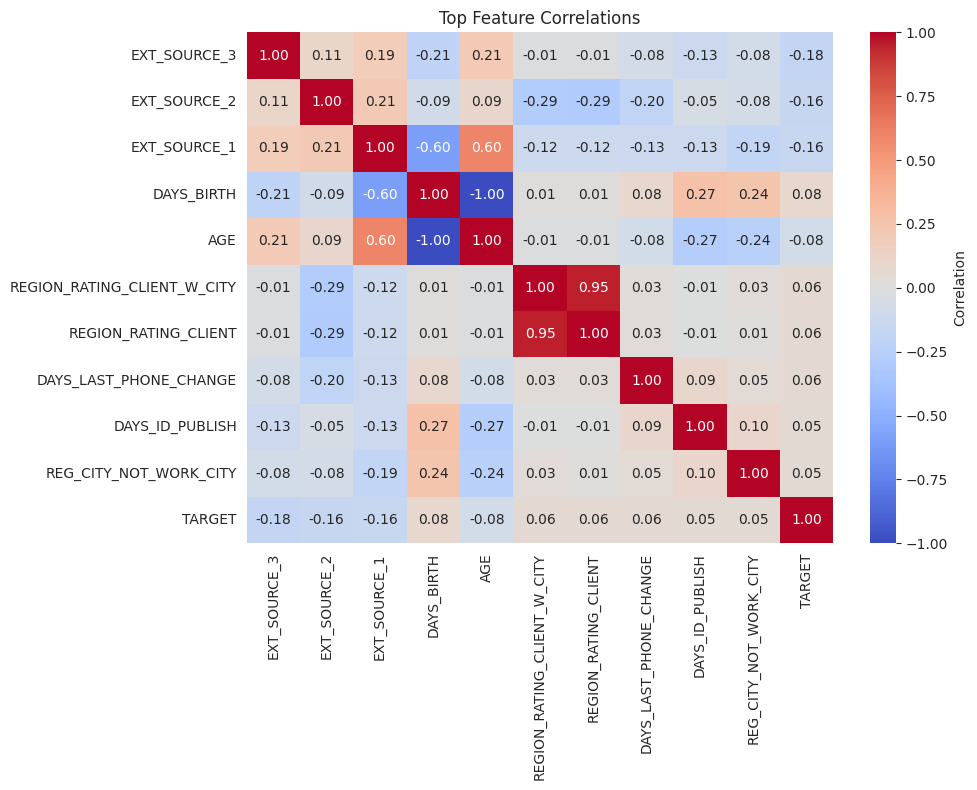

In [48]:
# Top feature heatmap - what correlate with what
top_features = target_corr.abs().nlargest(10).index.tolist() + ['TARGET']
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_train[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Top Feature Correlations')
plt.tight_layout()
# The visualisation is created fully by AI to show the information in comprehencible for view way

# MULTI-TABLE ANALYSIS (Previous Credit History)

In [49]:
# Load supplementary tables from competition files to also investigate them at least for a little
bureau_available = False
prev_app_available = False
bureau_balance_available = False

try:
    bureau = pd.read_csv(DATA_PATH / 'bureau.csv')
    bureau_available = True
    print(f"Bureau data loaded: {bureau.shape}")
    prev_app = pd.read_csv(DATA_PATH / 'previous_application.csv')
    prev_app_available = True
    print(f"Previous applications loaded: {prev_app.shape}")
    bureau_balance = pd.read_csv(DATA_PATH / 'bureau_balance.csv')
    bureau_balance_available = True
    print(f"Bureau balance data loaded: {bureau_balance.shape}")
except:
    print("Some of these are unavailable")

Bureau data loaded: (1716428, 17)
Previous applications loaded: (1670214, 37)
Bureau balance data loaded: (27299925, 3)


In [50]:
if bureau_available:
    # Previous credit count
    prev_credit = bureau.groupby('SK_ID_CURR').size().rename('PREV_CREDIT_COUNT')
    df_train = df_train.merge(prev_credit, left_on='SK_ID_CURR', right_index=True, how='left')
    df_train['PREV_CREDIT_COUNT'] = df_train['PREV_CREDIT_COUNT'].fillna(0)
    corr_prev = df_train['PREV_CREDIT_COUNT'].corr(df_train['TARGET'])
    print(f'Previous credit count -> default correlation: {corr_prev:.4f}')
    # Credit balance status
    status_dist = bureau['CREDIT_ACTIVE'].value_counts()
    print(f'Previous credit status distribution:\n{status_dist}')

Previous credit count -> default correlation: -0.0100
Previous credit status distribution:
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


In [51]:
if prev_app_available:
    # Previous approved applications
    approved = (prev_app['NAME_CONTRACT_STATUS'] == 'Approved').groupby(prev_app['SK_ID_CURR']).sum().rename('PREV_APPROVED')
    df_train = df_train.merge(approved, left_on='SK_ID_CURR', right_index=True, how='left')
    df_train['PREV_APPROVED'] = df_train['PREV_APPROVED'].fillna(0)
    corr_approved = df_train['PREV_APPROVED'].corr(df_train['TARGET'])
    print(f'Previous approved applications -> default correlation: {corr_approved:.4f}')
    # Previous application outcomes
    outcome_dist = prev_app['NAME_CONTRACT_STATUS'].value_counts()
    print(f'Previous application outcomes:\n{outcome_dist}')

Previous approved applications -> default correlation: -0.0235
Previous application outcomes:
NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [52]:
if bureau_available:
    # Delinquency history
    has_delinq = (bureau['CREDIT_DAY_OVERDUE'] > 0).groupby(bureau['SK_ID_CURR']).any().astype(int).rename('HAS_DELINQUENCY')
    df_train = df_train.merge(has_delinq, left_on='SK_ID_CURR', right_index=True, how='left')
    df_train['HAS_DELINQUENCY'] = df_train['HAS_DELINQUENCY'].fillna(0)
    corr_delinq = df_train['HAS_DELINQUENCY'].corr(df_train['TARGET'])
    print(f'Has delinquency history -> default correlation: {corr_delinq:.4f}')
    delinq_default = df_train.groupby('HAS_DELINQUENCY')['TARGET'].mean()
    print(f'Default rate by delinquency history:\n{delinq_default}')

Has delinquency history -> default correlation: 0.0304
Default rate by delinquency history:
HAS_DELINQUENCY
0.0    0.079855
1.0    0.158964
Name: TARGET, dtype: float64


# TRAIN/TEST DATA COMPARISON

In [53]:
print('SHAPE COMPARISON:')
print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"Common columns: {len(set(df_train.columns) & set(df_test.columns))}")
print(f"Train-only columns: {set(df_train.columns) - set(df_test.columns)}")

SHAPE COMPARISON:
Training set: (307511, 128)
Test set: (48744, 121)
Common columns: 121
Train-only columns: {'PREV_APPROVED', 'INTERACTION_AGE_EMPLOYED', 'PREV_CREDIT_COUNT', 'INTERACTION_CREDIT_INCOME', 'TARGET', 'AGE', 'HAS_DELINQUENCY'}


In [54]:
# Distribution differences in case it can be a deal
common_cols = [c for c in numeric_cols if c in df_test.columns]
top_common = target_corr.abs().nlargest(5).index.tolist()
top_common = [c for c in top_common if c in df_test.columns]

comparison = pd.DataFrame({
    'train_mean': df_train[top_common].mean(),
    'test_mean': df_test[top_common].mean(),
    'diff_pct': ((df_test[top_common].mean() - df_train[top_common].mean()) / (df_train[top_common].mean().abs() + 1) * 100).round(2)
})
print(comparison)

                train_mean     test_mean  diff_pct
EXT_SOURCE_3      0.510853      0.500106     -0.71
EXT_SOURCE_2      0.514393      0.518021      0.24
EXT_SOURCE_1      0.502130      0.501180     -0.06
DAYS_BIRTH   -16036.995067 -16068.084605     -0.19


In [55]:
# Missingness comparison
common_cols_all = [c for c in df_train.columns if c in df_test.columns]
missing_comparison = pd.DataFrame({
    'train_missing_%': (df_train[common_cols_all].isna().mean() * 100).round(2),
    'test_missing_%': (df_test[common_cols_all].isna().mean() * 100).round(2)
})
missing_comparison = missing_comparison[(missing_comparison['train_missing_%'] > 0) | (missing_comparison['test_missing_%'] > 0)]
print(missing_comparison.sort_values('train_missing_%', ascending=False))

                          train_missing_%  test_missing_%
COMMONAREA_AVG                      69.87           68.72
COMMONAREA_MEDI                     69.87           68.72
COMMONAREA_MODE                     69.87           68.72
NONLIVINGAPARTMENTS_MODE            69.43           68.41
NONLIVINGAPARTMENTS_AVG             69.43           68.41
...                                   ...             ...
OBS_30_CNT_SOCIAL_CIRCLE             0.33            0.06
DEF_60_CNT_SOCIAL_CIRCLE             0.33            0.06
EXT_SOURCE_2                         0.21            0.02
AMT_GOODS_PRICE                      0.09            0.00
AMT_ANNUITY                          0.00            0.05

[65 rows x 2 columns]


# EDA SUMMARY

In [56]:
print(f"Dataset Overview: {df_train.shape[0]:,} rows x {df_train.shape[1]} features")
print(f"Target Balance: {df_train['TARGET'].mean():.2%} defaulters (imbalanced)")
print(f"Missing Data: {df_train.isna().sum().sum():,} cells ({df_train.isna().sum().sum()/(df_train.shape[0]*df_train.shape[1])*100:.1f}%)")
print(f"Numeric Features: {len(numeric_cols)}")
print(f"Categorical Features: {len(cat_cols)}")
print(f"Supplementary Tables: Bureau={bureau_available}, PrevApp={prev_app_available}, BureauBalance={bureau_balance_available}")

Dataset Overview: 307,511 rows x 128 features
Target Balance: 8.07% defaulters (imbalanced)
Missing Data: 9,152,465 cells (23.3%)
Numeric Features: 106
Categorical Features: 16
Supplementary Tables: Bureau=True, PrevApp=True, BureauBalance=True
